In [1]:
from statistics import linear_regression

import pandas as pd
import numpy as np
from mlflow import sklearn
from pymupdf.table import extract_text
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.pipeline as pipeline
from torchvision.transforms.v2.functional import elastic

In [2]:
df = pd.read_csv("boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [5]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [6]:
df.shape

(506, 14)

In [7]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [8]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


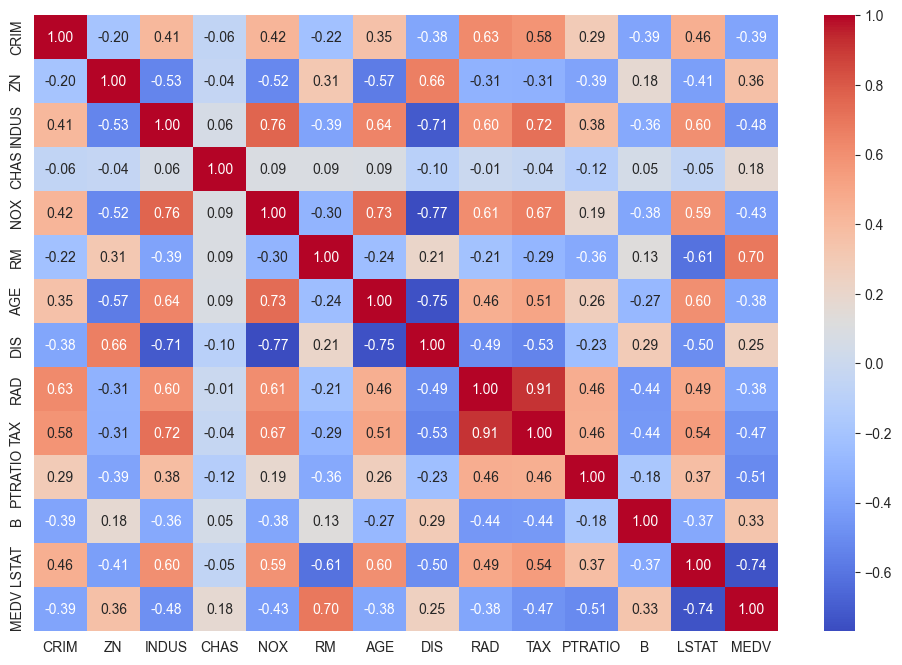

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [11]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [12]:
# dependent and independent variables
X = df.drop('MEDV', axis=1)
y = df['MEDV'] # target value

In [13]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [14]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [15]:
# train - test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=13)

In [16]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
51,0.04337,21.0,5.64,0,0.439,6.115,63.0,6.8147,4,243.0,16.8,393.97,9.43
265,0.76162,20.0,3.97,0,0.647,5.560,62.8,1.9865,5,264.0,13.0,392.40,10.45
66,0.04379,80.0,3.37,0,0.398,5.787,31.1,6.6115,4,337.0,16.1,396.90,10.24
12,0.09378,12.5,7.87,0,0.524,5.889,39.0,5.4509,5,311.0,15.2,390.50,15.71
347,0.01870,85.0,4.15,0,0.429,6.516,27.7,8.5353,4,351.0,17.9,392.43,6.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,0.53700,0.0,6.20,0,0.504,5.981,68.1,3.6715,8,307.0,17.4,378.35,11.65
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307.0,21.0,386.85,6.58
74,0.07896,0.0,12.83,0,0.437,6.273,6.0,4.2515,5,398.0,18.7,394.92,6.78
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296.0,16.6,393.23,10.11


In [17]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0,0.614,5.304,97.3,2.1007,24,666.0,20.2,349.48,24.91
451,5.44114,0.0,18.10,0,0.713,6.655,98.2,2.3552,24,666.0,20.2,355.29,17.73
29,1.00245,0.0,8.14,0,0.538,6.674,87.3,4.2390,4,307.0,21.0,380.23,11.98
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
312,0.26169,0.0,9.90,0,0.544,6.023,90.4,2.8340,4,304.0,18.4,396.30,11.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,15.28800,0.0,18.10,0,0.671,6.649,93.3,1.3449,24,666.0,20.2,363.02,23.24
90,0.04684,0.0,3.41,0,0.489,6.417,66.1,3.0923,2,270.0,17.8,392.18,8.81
78,0.05646,0.0,12.83,0,0.437,6.232,53.7,5.0141,5,398.0,18.7,386.40,12.34
44,0.12269,0.0,6.91,0,0.448,6.069,40.0,5.7209,3,233.0,17.9,389.39,9.55


In [18]:
corr = df.corr()
columns_for_drop_set = set()

def columns_dropping_def(df, treshold):
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > treshold:
                columns_for_drop_set.add(df.columns[i])
    return columns_for_drop_set

columns_dropping_def(X_train, 0.95)

set()

In [19]:
# Standardization
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled

array([[3.85648004e-04, 2.10000000e-01, 1.89882698e-01, ...,
        4.46808511e-01, 9.92611831e-01, 2.27203416e-01],
       [8.45885346e-03, 2.00000000e-01, 1.28665689e-01, ...,
        4.25531915e-02, 9.88652983e-01, 2.58310461e-01],
       [3.90368849e-04, 8.00000000e-01, 1.06671554e-01, ...,
        3.72340426e-01, 1.00000000e+00, 2.51906069e-01],
       ...,
       [7.85683343e-04, 0.00000000e+00, 4.53445748e-01, ...,
        6.48936170e-01, 9.95007313e-01, 1.46386093e-01],
       [6.87444825e-04, 0.00000000e+00, 1.31598240e-01, ...,
        4.25531915e-01, 9.90745877e-01, 2.47941446e-01],
       [2.69762521e-04, 0.00000000e+00, 1.73387097e-01, ...,
        8.08510638e-01, 9.98083615e-01, 1.99146081e-01]])

In [21]:
X_test_scaled

array([[1.68762759e-01, 0.00000000e+00, 6.46627566e-01, ...,
        8.08510638e-01, 8.80427656e-01, 6.99298567e-01],
       [6.10571499e-02, 0.00000000e+00, 6.46627566e-01, ...,
        8.08510638e-01, 8.95077916e-01, 4.80329369e-01],
       [1.11658080e-02, 0.00000000e+00, 2.81524927e-01, ...,
        8.93617021e-01, 9.57965606e-01, 3.04971028e-01],
       ...,
       [5.32780980e-04, 0.00000000e+00, 4.53445748e-01, ...,
        6.48936170e-01, 9.73523627e-01, 3.15949985e-01],
       [1.27721314e-03, 0.00000000e+00, 2.36436950e-01, ...,
        5.63829787e-01, 9.81063089e-01, 2.30863068e-01],
       [5.96287573e-04, 4.00000000e-01, 2.89589443e-02, ...,
        7.55319149e-01, 1.00000000e+00, 1.21988411e-01]])

In [22]:
# Linear Regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

linear = LinearRegression()
ridge = Ridge()
lasso = Lasso()
elasticnet = ElasticNet()

linear.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elasticnet.fit(X_train_scaled, y_train)

y_pred_linear = linear.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_elasticnet = elasticnet.predict(X_test_scaled)

In [23]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_score_linear = r2_score(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_score_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

mae_elasticnet = mean_absolute_error(y_test, y_pred_elasticnet)
mse_elasticnet = mean_squared_error(y_test, y_pred_elasticnet)
r2_score_elasticnet = r2_score(y_test, y_pred_elasticnet)
rmse_elasticnet = np.sqrt(mse_elasticnet)

In [24]:
print("Linear Regression Model Performance:")
print(f"Mean Squared Error: {mse_linear:.4f}")
print(f"Root Mean Squared Error: {rmse_linear:.4f}")
print(f"Mean Absolute Error: {mae_linear:.4f}")
print(f"R^2 Score: {r2_score_linear:.4f}")

Linear Regression Model Performance:
Mean Squared Error: 24.3182
Root Mean Squared Error: 4.9314
Mean Absolute Error: 3.6268
R^2 Score: 0.7318


In [25]:
print("Ridge Regression Model Performance:")
print(f"Mean Squared Error: {mse_ridge:.4f}")
print(f"Root Mean Squared Error: {rmse_ridge:.4f}")
print(f"Mean Absolute Error: {mae_ridge:.4f}")
print(f"R^2 Score: {r2_score_ridge:.4f}")

Ridge Regression Model Performance:
Mean Squared Error: 23.4375
Root Mean Squared Error: 4.8412
Mean Absolute Error: 3.4630
R^2 Score: 0.7415


In [26]:
print("Lasso Regression Model Performance:")
print(f"Mean Squared Error: {mse_lasso:.4f}")
print(f"Root Mean Squared Error: {rmse_lasso:.4f}")
print(f"Mean Absolute Error: {mae_lasso:.4f}")
print(f"R^2 Score: {r2_score_lasso:.4f}")

Lasso Regression Model Performance:
Mean Squared Error: 65.0429
Root Mean Squared Error: 8.0649
Mean Absolute Error: 6.0587
R^2 Score: 0.2826


In [27]:
print("ElasticNet Regression Model Performance:")
print(f"Mean Squared Error: {mse_elasticnet:.4f}")
print(f"Root Mean Squared Error: {rmse_elasticnet:.4f}")
print(f"Mean Absolute Error: {mae_elasticnet:.4f}")
print(f"R^2 Score: {r2_score_elasticnet:.4f}")

ElasticNet Regression Model Performance:
Mean Squared Error: 76.9160
Root Mean Squared Error: 8.7702
Mean Absolute Error: 6.4578
R^2 Score: 0.1516


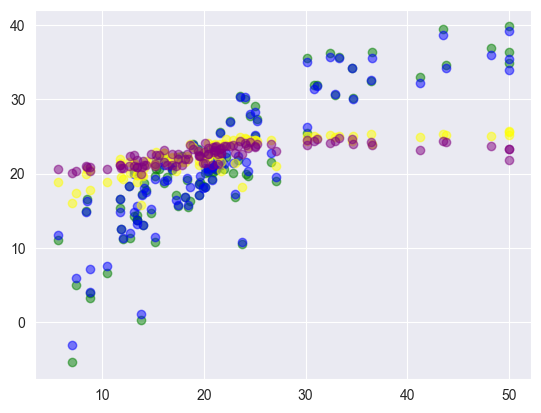

In [28]:
plt.scatter(y_test, y_pred_linear, c='g', label='Actual', alpha=0.5)
plt.scatter(y_test, y_pred_ridge, c='b', label='Actual', alpha=0.5 )
plt.scatter(y_test, y_pred_lasso, c='yellow', label='Actual', alpha=0.5 )
plt.scatter(y_test, y_pred_elasticnet, c='purple', label='Actual', alpha=0.5 )

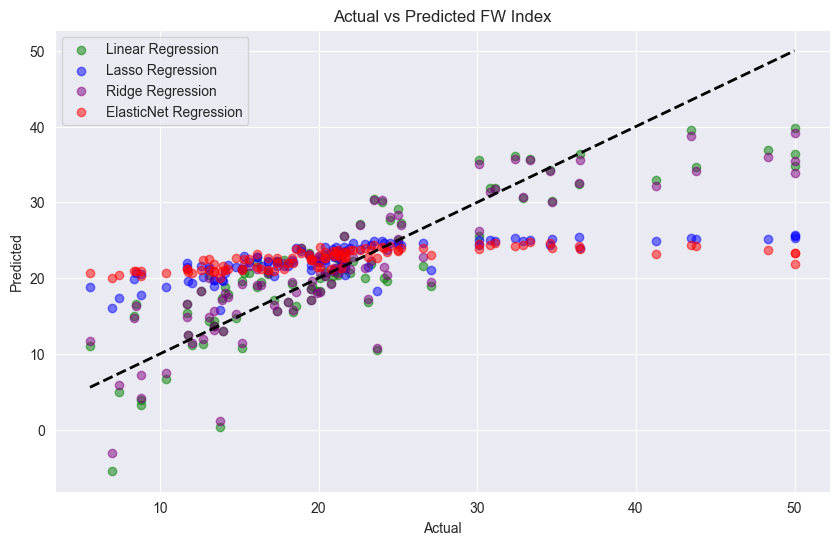

In [29]:
# Combine all plots
plt.figure(figsize=(10,6))
plt.scatter(y_test, linear.predict(X_test_scaled), c='g', label='Linear Regression', alpha=0.5)
plt.scatter(y_test, lasso.predict(X_test_scaled), c='b', label='Lasso Regression', alpha=0.5)
plt.scatter(y_test, ridge.predict(X_test_scaled), c='purple', label='Ridge Regression', alpha=0.5)
plt.scatter(y_test, elasticnet.predict(X_test_scaled), c='r', label='ElasticNet Regression', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted FW Index')
plt.legend()
plt.show()

In [30]:
# Cross Validation

# Linear Regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, RidgeCV, LassoCV, ElasticNetCV

ridge_cv = RidgeCV(cv=5)
lasso_cv = LassoCV(cv=5)
elasticnet_cv = ElasticNetCV(cv=5)

ridge_cv.fit(X_train_scaled, y_train)
lasso_cv.fit(X_train_scaled, y_train)
elasticnet_cv.fit(X_train_scaled, y_train)

y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
y_pred_elasticnet_cv = elasticnet_cv.predict(X_test_scaled)

In [31]:
mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_score_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
rmse_ridge_cv = np.sqrt(mse_ridge_cv)

mae_lasso_cv = mean_absolute_error(y_test, y_pred_lasso_cv)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_score_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
rmse_lasso_cv = np.sqrt(mse_lasso_cv)

mae_elasticnet_cv = mean_absolute_error(y_test, y_pred_elasticnet_cv)
mse_elasticnet_cv = mean_squared_error(y_test, y_pred_elasticnet_cv)
r2_score_elasticnet_cv = r2_score(y_test, y_pred_elasticnet_cv)
rmse_elasticnet_cv = np.sqrt(mse_elasticnet_cv)

In [32]:
print("RidgeCV Regression Model Performance:")
print(f"Mean Squared Error: {mse_ridge_cv:.4f}")
print(f"Root Mean Squared Error: {rmse_ridge_cv:.4f}")
print(f"Mean Absolute Error: {mae_ridge_cv:.4f}")
print(f"R^2 Score: {r2_score_ridge_cv:.4f}")

RidgeCV Regression Model Performance:
Mean Squared Error: 24.1371
Root Mean Squared Error: 4.9130
Mean Absolute Error: 3.6007
R^2 Score: 0.7338


In [33]:
print("LassoCV Regression Model Performance:")
print(f"Mean Squared Error: {mse_lasso_cv:.4f}")
print(f"Root Mean Squared Error: {rmse_lasso_cv:.4f}")
print(f"Mean Absolute Error: {mae_lasso_cv:.4f}")
print(f"R^2 Score: {r2_score_lasso_cv:.4f}")

LassoCV Regression Model Performance:
Mean Squared Error: 23.9859
Root Mean Squared Error: 4.8975
Mean Absolute Error: 3.5786
R^2 Score: 0.7354


In [34]:
print("ElasticNetCV Regression Model Performance:")
print(f"Mean Squared Error: {mse_elasticnet_cv:.4f}")
print(f"Root Mean Squared Error: {rmse_elasticnet_cv:.4f}")
print(f"Mean Absolute Error: {mae_elasticnet_cv:.4f}")
print(f"R^2 Score: {r2_score_elasticnet_cv:.4f}")

ElasticNetCV Regression Model Performance:
Mean Squared Error: 23.5787
Root Mean Squared Error: 4.8558
Mean Absolute Error: 3.5056
R^2 Score: 0.7399


In [35]:
X_test_scaled

array([[1.68762759e-01, 0.00000000e+00, 6.46627566e-01, ...,
        8.08510638e-01, 8.80427656e-01, 6.99298567e-01],
       [6.10571499e-02, 0.00000000e+00, 6.46627566e-01, ...,
        8.08510638e-01, 8.95077916e-01, 4.80329369e-01],
       [1.11658080e-02, 0.00000000e+00, 2.81524927e-01, ...,
        8.93617021e-01, 9.57965606e-01, 3.04971028e-01],
       ...,
       [5.32780980e-04, 0.00000000e+00, 4.53445748e-01, ...,
        6.48936170e-01, 9.73523627e-01, 3.15949985e-01],
       [1.27721314e-03, 0.00000000e+00, 2.36436950e-01, ...,
        5.63829787e-01, 9.81063089e-01, 2.30863068e-01],
       [5.96287573e-04, 4.00000000e-01, 2.89589443e-02, ...,
        7.55319149e-01, 1.00000000e+00, 1.21988411e-01]])

In [36]:
linear.predict(X_test_scaled)

array([11.23728132, 19.65693542, 20.77279453, 30.01783844, 23.34685884,
       22.27047398, 21.84486005, 20.61260546, 19.29666529,  0.36793865,
       18.92138754, 18.959503  , 36.31015707, 10.7659897 , 15.33471911,
       18.80208983, 17.08008653, 20.87257606, 30.52648473, 21.66712266,
       36.16920572, 30.49725218, 22.87941979, 14.33087637, 18.34617256,
        6.67852144, 34.83033225, 16.82964023, 14.40608322, 19.66712403,
       29.10945203,  5.01376207, -5.40629161, 20.61394839, 20.68508527,
       14.9745791 , 19.50390664, 16.88251618, 34.65145054, 16.60728312,
       16.37781386, 20.78072572, 36.34448399, 12.53464158, 15.65838997,
       35.71307371, 14.72150456,  3.23413117, 21.60588655, 20.53810441,
       35.59894025, 10.52440061, 39.7987333 , 17.13435228, 22.09022132,
       20.00130664, 20.78652117, 32.47699491, 32.93750073, 23.42028846,
       21.89455379, 13.06687124, 21.17908961, 20.21627944, 22.28007322,
       30.16539802, 27.71540332, 16.52474502, 17.85753808, 20.41

In [37]:
y_test

477    12.0
451    15.2
29     21.0
0      24.0
312    19.4
       ... 
376    13.9
90     22.6
78     21.2
44     21.2
350    22.9
Name: MEDV, Length: 102, dtype: float64